In [44]:
import os
import time
import zipfile
import urllib.request

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
from torchvision import datasets, transforms, models

In [45]:
imagenet_mean = [0.485,0.456,0.406]
imagenet_std = [0.229, 0.224,0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.ToTensor()
])

In [46]:
full_dataset = torchvision.datasets.OxfordIIITPet(
    root="./data",
    split="trainval",
    target_types="category",
    download=True
)

class_labels = full_dataset.classes

print("Total:", len(full_dataset))
print("Classes:", class_labels)

Total: 3680
Classes: ['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle', 'Bengal', 'Birman', 'Bombay', 'Boxer', 'British Shorthair', 'Chihuahua', 'Egyptian Mau', 'English Cocker Spaniel', 'English Setter', 'German Shorthaired', 'Great Pyrenees', 'Havanese', 'Japanese Chin', 'Keeshond', 'Leonberger', 'Maine Coon', 'Miniature Pinscher', 'Newfoundland', 'Persian', 'Pomeranian', 'Pug', 'Ragdoll', 'Russian Blue', 'Saint Bernard', 'Samoyed', 'Scottish Terrier', 'Shiba Inu', 'Siamese', 'Sphynx', 'Staffordshire Bull Terrier', 'Wheaten Terrier', 'Yorkshire Terrier']


In [47]:
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_indices, val_indices = random_split(
    range(len(full_dataset)),
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

In [48]:
train_dataset_full = torchvision.datasets.OxfordIIITPet(
    root="./data",
    split="trainval",
    target_types="category",
    transform=train_transform
)

val_dataset_full = torchvision.datasets.OxfordIIITPet(
    root="./data",
    split="trainval",
    target_types="category",
    transform=val_transform
)

train_dataset = torch.utils.data.Subset(
    train_dataset_full,
    train_indices.indices
)

val_dataset = torch.utils.data.Subset(
    val_dataset_full,
    val_indices.indices
)

In [49]:
class_labels = full_dataset.classes
print(class_labels)

['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle', 'Bengal', 'Birman', 'Bombay', 'Boxer', 'British Shorthair', 'Chihuahua', 'Egyptian Mau', 'English Cocker Spaniel', 'English Setter', 'German Shorthaired', 'Great Pyrenees', 'Havanese', 'Japanese Chin', 'Keeshond', 'Leonberger', 'Maine Coon', 'Miniature Pinscher', 'Newfoundland', 'Persian', 'Pomeranian', 'Pug', 'Ragdoll', 'Russian Blue', 'Saint Bernard', 'Samoyed', 'Scottish Terrier', 'Shiba Inu', 'Siamese', 'Sphynx', 'Staffordshire Bull Terrier', 'Wheaten Terrier', 'Yorkshire Terrier']


In [50]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

images.shape: torch.Size([64, 3, 224, 224])
labels.shape: torch.Size([64])


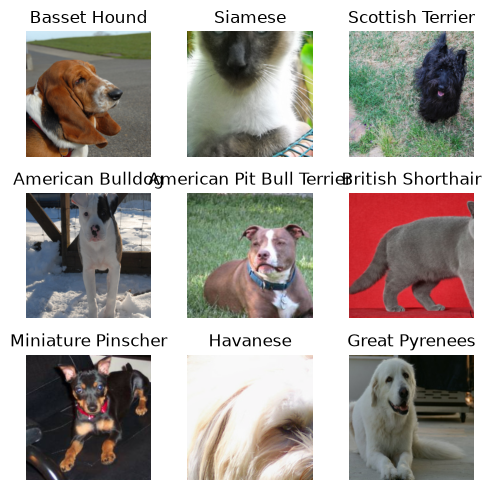

In [51]:
images,labels = next(iter(train_loader))
print("images.shape:",images.shape)
print("labels.shape:",labels.shape)

mean = torch.tensor(imagenet_mean).view(3,1,1)
std = torch.tensor(imagenet_std).view(3,1,1)

fig, axes = plt.subplots(3, 3, figsize=(5, 5))

for i, ax in enumerate(axes.flat):
    img = (images[i] * std + mean).clamp(0, 1)

    ax.imshow(img.permute(1, 2, 0).numpy())
    ax.set_title(class_labels[labels[i]])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [52]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [53]:
#Transferred Model
t_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT).to(device)
print(t_model.fc)

Linear(in_features=512, out_features=1000, bias=True)


In [54]:
for param in t_model.parameters():
  param.requires_grad = False

In [55]:
num_features = t_model.fc.in_features
t_model.fc = nn.Linear(num_features, len(class_labels))

t_model = t_model.to(device)

In [56]:
print(t_model.fc)
total_params = sum(p.numel() for p in t_model.parameters())
train_params = sum(p.numel() for p in t_model.parameters() if p.requires_grad)
print(total_params)
print(train_params)

Linear(in_features=512, out_features=37, bias=True)
11195493
18981


In [57]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(t_model.fc.parameters(),lr=0.001)

In [58]:
def evaluate(model,loader):
  model.eval()
  running_loss,correct,total = 0.0,0,0

  with torch.no_grad():
    for inputs, labels in loader:
      inputs,labels = inputs.to(device), labels.to(device)

      outputs = model(inputs)
      loss = criterion(outputs, labels)

      running_loss += loss.item() * inputs.size(0)
      correct += (outputs.argmax(dim=1) == labels).sum().item()
      total += labels.size(0)
  return running_loss/total, correct/total

In [59]:
def train_one_epoch(model, loader, optimizer):
  model.train()
  running_loss, correct, total = 0.0,0,0

  for inputs,labels in loader:
    inputs,labels = inputs.to(device), labels.to(device)

    optimizer.zero_grad()
    outputs = model(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    running_loss += loss.item() * inputs.size(0)
    correct += (outputs.argmax(dim=1) == labels).sum().item()
    total += labels.size(0)
  return running_loss/total, correct/total

In [60]:
results = {}

In [61]:
history = {"train_loss":[],"train_acc":[],"val_loss":[],"val_acc":[]}
epochs = 10
total_start = time.time()

for epoch in range(epochs):
  start = time.time()
  train_loss, train_acc = train_one_epoch(t_model, train_loader, optimizer)
  val_loss, val_acc = evaluate(t_model, val_loader)

  history["train_loss"].append(train_loss)
  history["train_acc"].append(train_acc)
  history["val_loss"].append(val_loss)
  history["val_acc"].append(val_acc)

  print(f"Epoch {epoch+1}/{epochs} |"
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} |"
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} |"
        f"{time.time()-start:.0f}s"
  )

  total_time = time.time() - total_start

print("\nTraining complete.")
print(f"Total training time: {total_time:.1f}s")
print(f"Total training time: {total_time / 60:.2f} minutes")

results["t_model"] = history

Epoch 1/10 |Train Loss: 2.6562 | Train Acc: 0.3624 |Val Loss: 1.5168 | Val Acc: 0.7106 |5s
Epoch 2/10 |Train Loss: 1.4571 | Train Acc: 0.6936 |Val Loss: 0.8535 | Val Acc: 0.8478 |6s
Epoch 3/10 |Train Loss: 1.0411 | Train Acc: 0.7779 |Val Loss: 0.6427 | Val Acc: 0.8668 |6s
Epoch 4/10 |Train Loss: 0.8743 | Train Acc: 0.8003 |Val Loss: 0.5346 | Val Acc: 0.8859 |6s
Epoch 5/10 |Train Loss: 0.7861 | Train Acc: 0.8118 |Val Loss: 0.4817 | Val Acc: 0.8845 |7s
Epoch 6/10 |Train Loss: 0.7134 | Train Acc: 0.8200 |Val Loss: 0.4228 | Val Acc: 0.9049 |8s
Epoch 7/10 |Train Loss: 0.6695 | Train Acc: 0.8308 |Val Loss: 0.3999 | Val Acc: 0.9103 |7s
Epoch 8/10 |Train Loss: 0.6301 | Train Acc: 0.8380 |Val Loss: 0.3809 | Val Acc: 0.9035 |7s
Epoch 9/10 |Train Loss: 0.5926 | Train Acc: 0.8454 |Val Loss: 0.3746 | Val Acc: 0.8954 |7s
Epoch 10/10 |Train Loss: 0.5669 | Train Acc: 0.8499 |Val Loss: 0.3516 | Val Acc: 0.9035 |6s

Training complete.
Total training time: 63.3s
Total training time: 1.05 minutes


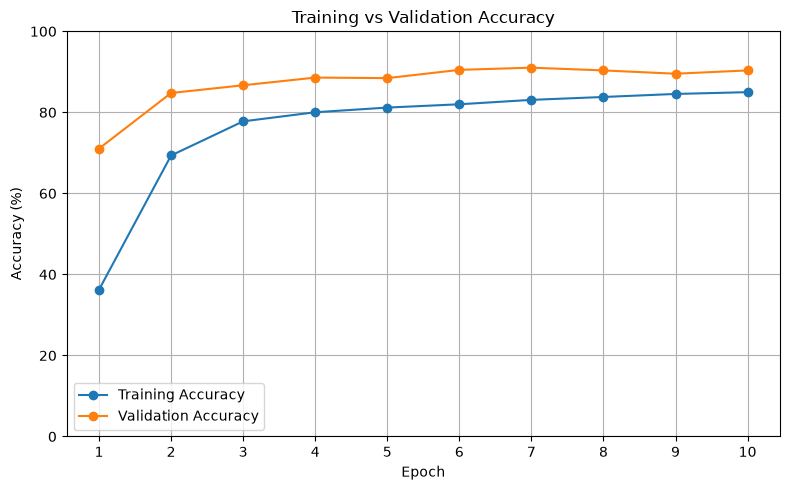

In [62]:
epochs = list(range(1, len(history["train_acc"]) + 1))

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    [acc * 100 for acc in history["train_acc"]],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs,
    [acc * 100 for acc in history["val_acc"]],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")

plt.xticks(epochs)
plt.ylim(0, 100)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [63]:
#Tuned Model
tu_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT).to(device)

In [64]:
for param in tu_model.parameters():
    param.requires_grad = False

for param in tu_model.layer4.parameters():
    param.requires_grad = True

In [65]:
num_features = tu_model.fc.in_features
tu_model.fc = nn.Linear(num_features, len(class_labels))

tu_model = tu_model.to(device)

In [66]:
print(tu_model.fc)
total_params = sum(p.numel() for p in tu_model.parameters())
train_params = sum(p.numel() for p in tu_model.parameters() if p.requires_grad)
print(total_params)
print(train_params)

Linear(in_features=512, out_features=37, bias=True)
11195493
8412709


In [67]:
tu_optimizer = optim.Adam([
    {"params": tu_model.layer4.parameters(), "lr": 1e-4},
    {"params": tu_model.fc.parameters(), "lr": 1e-3},
])

In [68]:
history = {"train_loss":[],"train_acc":[],"val_loss":[],"val_acc":[]}
epochs = 10
total_start = time.time()

for epoch in range(epochs):
  start = time.time()
  train_loss, train_acc = train_one_epoch(tu_model, train_loader, tu_optimizer)
  val_loss, val_acc = evaluate(tu_model, val_loader)

  history["train_loss"].append(train_loss)
  history["train_acc"].append(train_acc)
  history["val_loss"].append(val_loss)
  history["val_acc"].append(val_acc)

  print(f"Epoch {epoch+1}/{epochs} |"
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} |"
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} |"
        f"{time.time()-start:.0f}s"
  )

  total_time = time.time() - total_start

print("\nTraining complete.")
print(f"Total training time: {total_time:.1f}s")
print(f"Total training time: {total_time / 60:.2f} minutes")
results["tu_model"] = history

Epoch 1/10 |Train Loss: 1.9339 | Train Acc: 0.5486 |Val Loss: 0.6281 | Val Acc: 0.8533 |6s
Epoch 2/10 |Train Loss: 0.7828 | Train Acc: 0.8047 |Val Loss: 0.4190 | Val Acc: 0.8886 |7s
Epoch 3/10 |Train Loss: 0.5559 | Train Acc: 0.8448 |Val Loss: 0.3183 | Val Acc: 0.9090 |7s
Epoch 4/10 |Train Loss: 0.4827 | Train Acc: 0.8607 |Val Loss: 0.3170 | Val Acc: 0.9076 |7s
Epoch 5/10 |Train Loss: 0.4309 | Train Acc: 0.8770 |Val Loss: 0.2915 | Val Acc: 0.9062 |7s
Epoch 6/10 |Train Loss: 0.4047 | Train Acc: 0.8872 |Val Loss: 0.2985 | Val Acc: 0.9035 |7s
Epoch 7/10 |Train Loss: 0.3491 | Train Acc: 0.8981 |Val Loss: 0.2636 | Val Acc: 0.9198 |7s
Epoch 8/10 |Train Loss: 0.3250 | Train Acc: 0.9090 |Val Loss: 0.2551 | Val Acc: 0.9239 |8s
Epoch 9/10 |Train Loss: 0.3067 | Train Acc: 0.9110 |Val Loss: 0.2394 | Val Acc: 0.9212 |7s
Epoch 10/10 |Train Loss: 0.2672 | Train Acc: 0.9270 |Val Loss: 0.2514 | Val Acc: 0.9130 |7s

Training complete.
Total training time: 68.5s
Total training time: 1.14 minutes


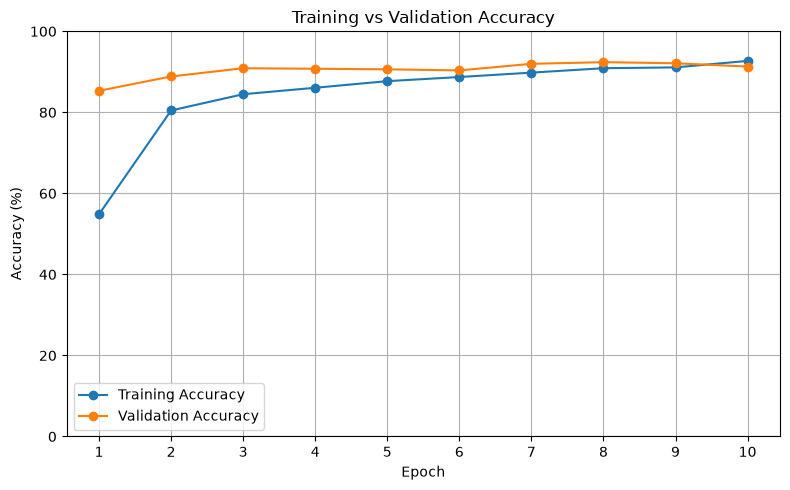

In [69]:
epochs = list(range(1, len(history["train_acc"]) + 1))

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    [acc * 100 for acc in history["train_acc"]],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs,
    [acc * 100 for acc in history["val_acc"]],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")

plt.xticks(epochs)
plt.ylim(0, 100)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [70]:
import torch.nn.functional as F

In [71]:
#Custom Model
custom_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

custom_val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

In [72]:
custom_train_full = torchvision.datasets.OxfordIIITPet(
    root="./data",
    split="trainval",
    target_types="category",
    transform=custom_train_transform
)

custom_val_full = torchvision.datasets.OxfordIIITPet(
    root="./data",
    split="trainval",
    target_types="category",
    transform=custom_val_transform
)

custom_train_dataset = torch.utils.data.Subset(
    custom_train_full,
    train_indices.indices
)

custom_val_dataset = torch.utils.data.Subset(
    custom_val_full,
    val_indices.indices
)

In [73]:
custom_train_loader = DataLoader(
    custom_train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2
)

custom_val_loader = DataLoader(
    custom_val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2
)

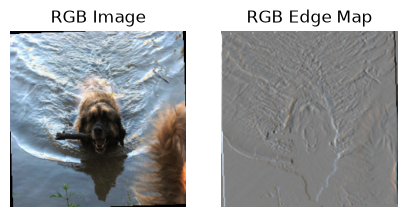

In [74]:
image, label = custom_train_dataset[0]

edge_kernel = torch.tensor([
    [-1., 0., 1.],
    [-2., 0., 2.],
    [-1., 0., 1.]
]).view(1, 1, 3, 3)

mean = torch.tensor(imagenet_mean).view(3, 1, 1)
std = torch.tensor(imagenet_std).view(3, 1, 1)

image_denorm = (image * std + mean).clamp(0, 1)

sample = image_denorm.unsqueeze(0)
edge_kernel_rgb = edge_kernel.repeat(3, 1, 1, 1)

edge_map = F.conv2d(
    sample,
    edge_kernel_rgb,
    padding=1,
    groups=3
)

fig, axes = plt.subplots(1, 2, figsize=(5, 3))

axes[0].imshow(sample[0].permute(1, 2, 0))
axes[0].set_title("RGB Image")

edge_display = edge_map[0].permute(1, 2, 0)

edge_display = (
    edge_display - edge_display.min()
) / (
    edge_display.max() - edge_display.min()
)

axes[1].imshow(edge_display)
axes[1].set_title("RGB Edge Map")

axes[0].axis("off")
axes[1].axis("off")

plt.show()

In [75]:
class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(256, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((4, 4))
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv(x)
        return self.fc(x)

In [76]:
c_model_10 = CNN(len(class_labels)).to(device)

In [77]:
criterion = nn.CrossEntropyLoss()

custom_optimizer = optim.Adam(
    c_model_10.parameters(),
    lr=0.001,
    weight_decay=1e-4
)
custom_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    custom_optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

In [78]:
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

epochs = 10
total_start = time.time()

for epoch in range(epochs):

    start = time.time()

    train_loss, train_acc = train_one_epoch(
        c_model_10,
        custom_train_loader,
        custom_optimizer
    )

    val_loss, val_acc = evaluate(
        c_model_10,
        custom_val_loader
    )

    custom_scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"{time.time()-start:.0f}s"
    )

total_time = time.time() - total_start

print("\nTraining complete.")
print(f"Total training time: {total_time:.1f}s")
print(f"Total training time: {total_time / 60:.2f} minutes")

results["c_model_10"] = history

Epoch 1/10 | Train Loss: 3.8187 | Train Acc: 0.0279 | Val Loss: 3.6118 | Val Acc: 0.0204 | 10s
Epoch 2/10 | Train Loss: 3.6111 | Train Acc: 0.0299 | Val Loss: 3.6118 | Val Acc: 0.0190 | 10s
Epoch 3/10 | Train Loss: 3.6111 | Train Acc: 0.0296 | Val Loss: 3.6127 | Val Acc: 0.0163 | 10s
Epoch 4/10 | Train Loss: 3.6107 | Train Acc: 0.0306 | Val Loss: 3.6136 | Val Acc: 0.0177 | 10s
Epoch 5/10 | Train Loss: 3.6108 | Train Acc: 0.0245 | Val Loss: 3.6114 | Val Acc: 0.0285 | 10s
Epoch 6/10 | Train Loss: 3.6053 | Train Acc: 0.0333 | Val Loss: 3.6086 | Val Acc: 0.0245 | 11s
Epoch 7/10 | Train Loss: 3.5980 | Train Acc: 0.0329 | Val Loss: 3.5997 | Val Acc: 0.0272 | 11s
Epoch 8/10 | Train Loss: 3.5825 | Train Acc: 0.0343 | Val Loss: 3.5840 | Val Acc: 0.0272 | 11s
Epoch 9/10 | Train Loss: 3.5669 | Train Acc: 0.0346 | Val Loss: 3.5646 | Val Acc: 0.0340 | 10s
Epoch 10/10 | Train Loss: 3.5663 | Train Acc: 0.0312 | Val Loss: 3.5640 | Val Acc: 0.0394 | 11s

Training complete.
Total training time: 103.1s
T

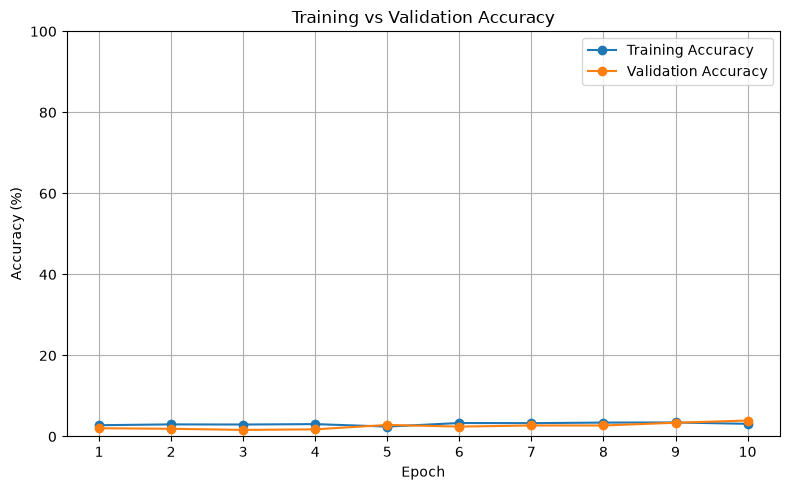

In [79]:
epochs = list(range(1, len(history["train_acc"]) + 1))

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    [acc * 100 for acc in history["train_acc"]],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs,
    [acc * 100 for acc in history["val_acc"]],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")

plt.xticks(epochs)
plt.ylim(0, 100)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [80]:
c_model_30 = CNN(len(class_labels)).to(device)

In [81]:
criterion = nn.CrossEntropyLoss()

custom_optimizer = optim.Adam(
    c_model_30.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

custom_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    custom_optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

In [82]:
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

epochs = 50

total_start = time.time()
for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(
        c_model_30,
        custom_train_loader,
        custom_optimizer
    )

    val_loss, val_acc = evaluate(
        c_model_30,
        custom_val_loader
    )

    custom_scheduler.step(val_loss)

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

total_time = time.time() - total_start

print("\nTraining complete.")
print(f"Total training time: {total_time:.1f}s")
print(f"Total training time: {total_time / 60:.2f} minutes")
results["c_model_30"] = history

Epoch 1/50 | Train Loss: 3.7803 | Train Acc: 0.0289 | Val Loss: 3.6129 | Val Acc: 0.0204
Epoch 2/50 | Train Loss: 3.6116 | Train Acc: 0.0289 | Val Loss: 3.6132 | Val Acc: 0.0204
Epoch 3/50 | Train Loss: 3.6112 | Train Acc: 0.0289 | Val Loss: 3.6135 | Val Acc: 0.0204
Epoch 4/50 | Train Loss: 3.6111 | Train Acc: 0.0289 | Val Loss: 3.6139 | Val Acc: 0.0204
Epoch 5/50 | Train Loss: 3.6109 | Train Acc: 0.0289 | Val Loss: 3.6141 | Val Acc: 0.0204
Epoch 6/50 | Train Loss: 3.6107 | Train Acc: 0.0289 | Val Loss: 3.6143 | Val Acc: 0.0204
Epoch 7/50 | Train Loss: 3.6107 | Train Acc: 0.0289 | Val Loss: 3.6145 | Val Acc: 0.0204
Epoch 8/50 | Train Loss: 3.6106 | Train Acc: 0.0289 | Val Loss: 3.6146 | Val Acc: 0.0204
Epoch 9/50 | Train Loss: 3.6106 | Train Acc: 0.0289 | Val Loss: 3.6147 | Val Acc: 0.0204
Epoch 10/50 | Train Loss: 3.6105 | Train Acc: 0.0289 | Val Loss: 3.6148 | Val Acc: 0.0204
Epoch 11/50 | Train Loss: 3.6104 | Train Acc: 0.0289 | Val Loss: 3.6149 | Val Acc: 0.0204
Epoch 12/50 | Train

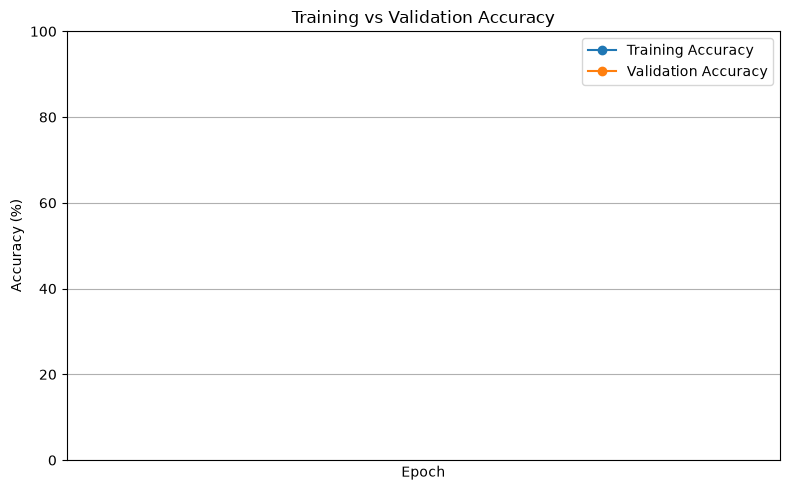

In [86]:
epochs = list(range(1, len(history["train_acc"]) + 1))

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    [acc * 100 for acc in history["train_acc"]],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs,
    [acc * 100 for acc in history["val_acc"]],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")

plt.xticks(epochs)
plt.ylim(0, 100)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

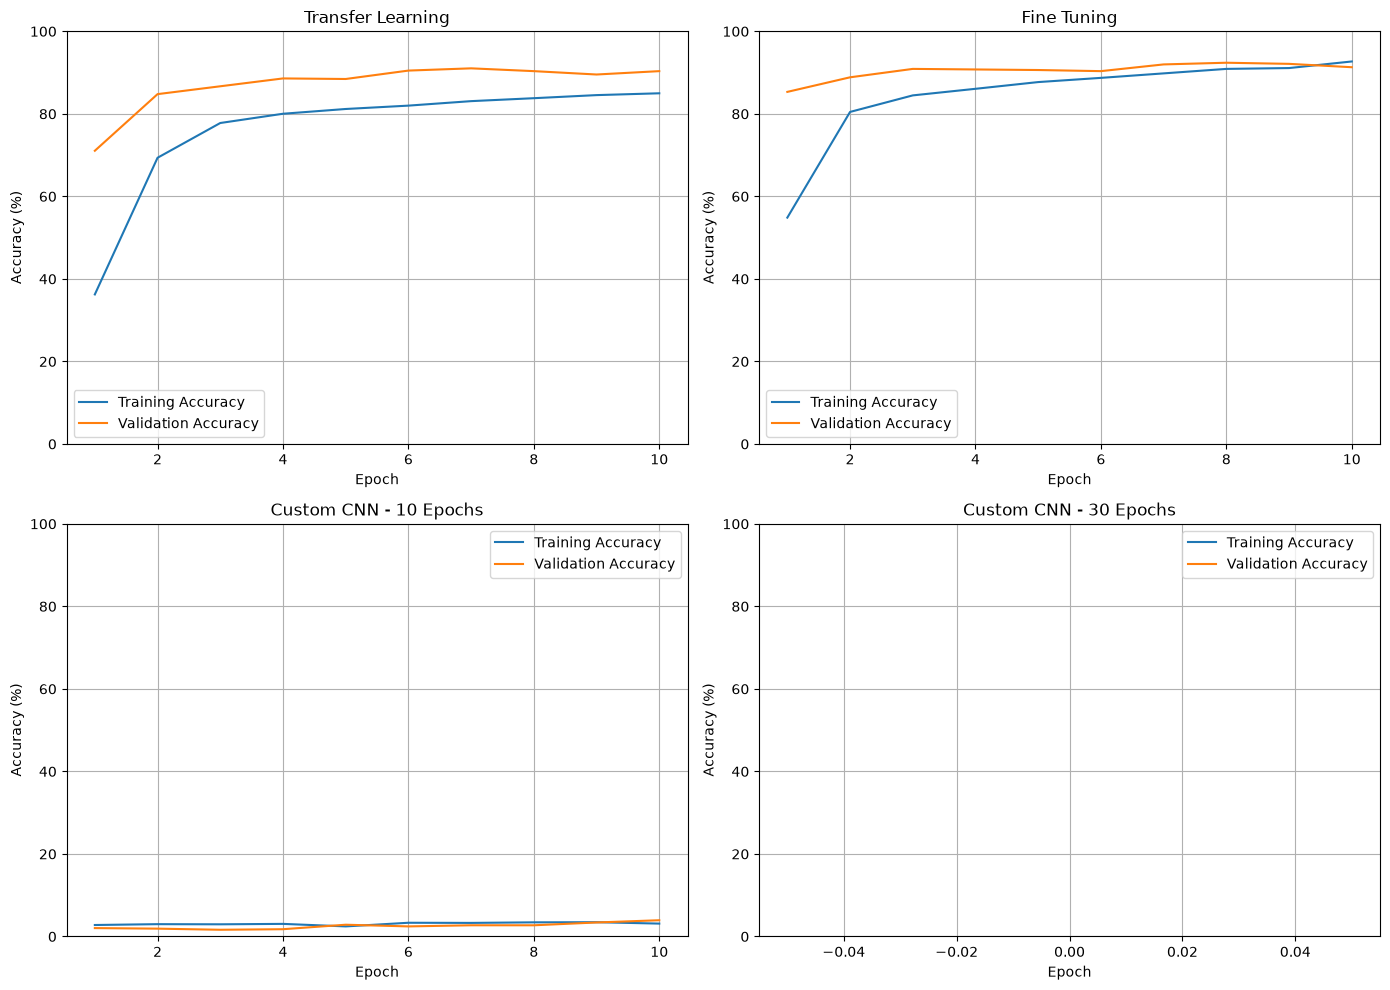

In [87]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

models_to_plot = [
    ("t_model", "Transfer Learning"),
    ("tu_model", "Fine Tuning"),
    ("c_model_10", "Custom CNN - 10 Epochs"),
    ("c_model_30", "Custom CNN - 30 Epochs")
]

for ax, (key, title) in zip(axes.flat, models_to_plot):

    history = results[key]
    epochs = range(1, len(history["train_acc"]) + 1)

    ax.plot(
        epochs,
        [x * 100 for x in history["train_acc"]],
        label="Training Accuracy"
    )

    ax.plot(
        epochs,
        [x * 100 for x in history["val_acc"]],
        label="Validation Accuracy"
    )

    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy (%)")
    ax.set_ylim(0, 100)
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

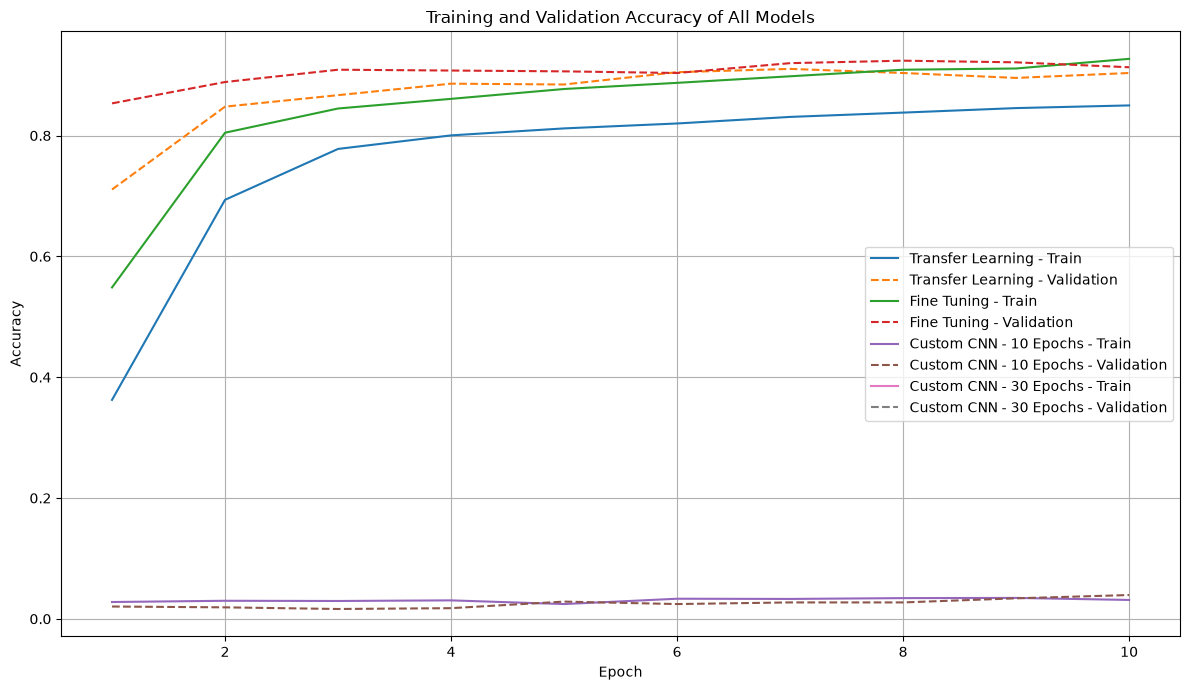

In [88]:
plt.figure(figsize=(12, 7))

models_to_plot = [
    ("t_model", "Transfer Learning"),
    ("tu_model", "Fine Tuning"),
    ("c_model_10", "Custom CNN - 10 Epochs"),
    ("c_model_30", "Custom CNN - 30 Epochs")
]

for key, name in models_to_plot:
    history = results[key]
    epochs = range(1, len(history["train_acc"]) + 1)

    plt.plot(
        epochs,
        history["train_acc"],
        label=f"{name} - Train"
    )

    plt.plot(
        epochs,
        history["val_acc"],
        linestyle="--",
        label=f"{name} - Validation"
    )

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy of All Models")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [89]:
torch.save(t_model.state_dict(), "models/t_model.pth")